# Predictive Maintenance System

## Milestone 2: Data Understanding

### Objective
Understand the dataset before performing any preprocessing or model training.

### Questions to Answer
- What does each feature represent?
- What is the target variable?
- Are there missing values?
- What are the data types?
- Is the dataset balanced?

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import sys
print(sys.executable)

c:\Users\HP\OneDrive\Desktop\Predictive-Maintenance-System 1\.venv\Scripts\python.exe


In [27]:
import pandas as pd
df_raw= pd.read_csv("../data/raw/ai4i2020.csv")
df = df_raw.copy()

In [28]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [29]:
df.shape

(10000, 14)

In [30]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [31]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [32]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [35]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [36]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_data

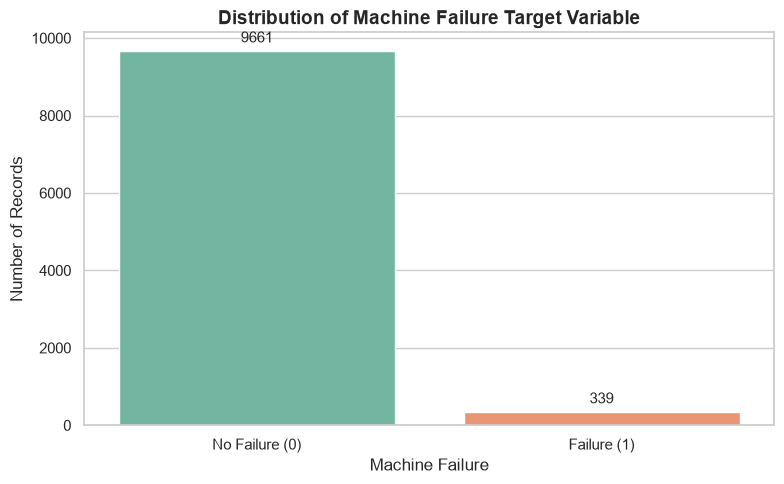

In [37]:
# Use a clean, professional plotting style.
sns.set_theme(style="whitegrid", context="notebook")

# Create a count plot to inspect class balance in the target variable.
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x="Machine failure",
    hue="Machine failure",
    palette="Set2",
    legend=False,
)

# Display the count above each bar for quick interpretation.
for bar in ax.containers:
    ax.bar_label(bar, fmt="%d", padding=4, fontsize=11)

ax.set_title("Distribution of Machine Failure Target Variable", fontsize=14, fontweight="bold")
ax.set_xlabel("Machine Failure", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Failure (0)", "Failure (1)"])

plt.tight_layout()
plt.show()

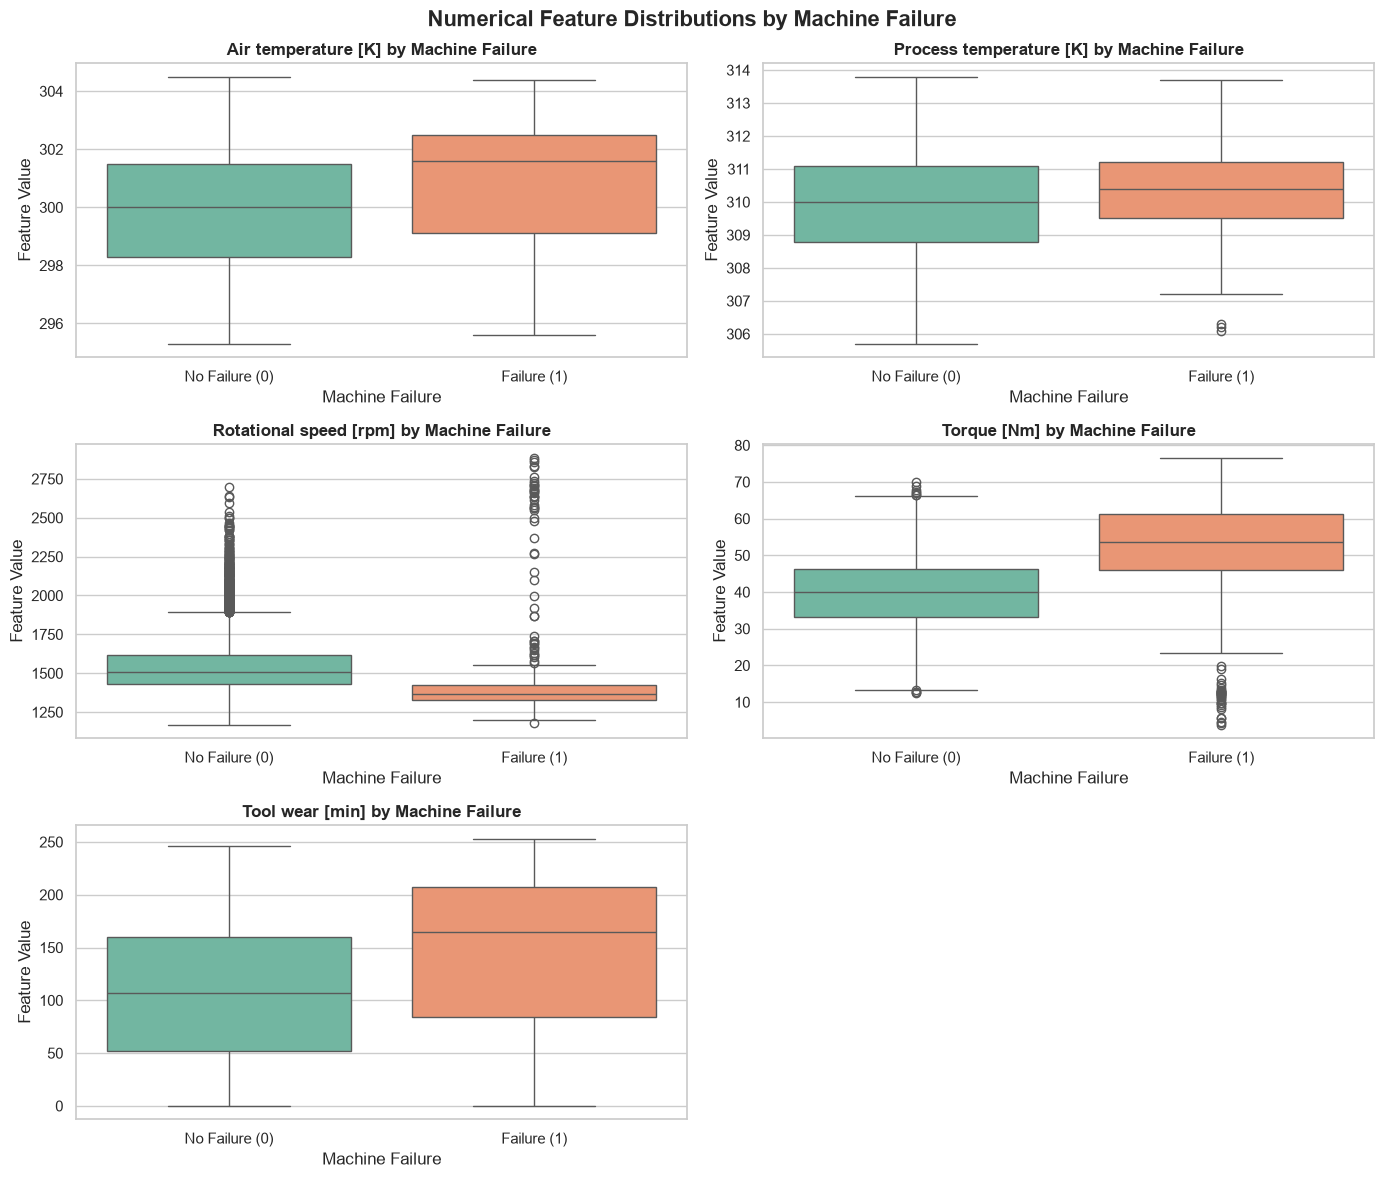

In [38]:
# Numerical features to compare against the target variable.
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# Use a 3x2 grid so each feature has a dedicated, readable subplot.
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

# Create one boxplot per numerical feature, grouped by machine failure status.
for ax, feature in zip(axes, numerical_features):
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature,
        hue="Machine failure",
        palette="Set2",
        legend=False,
        ax=ax,
    )

    ax.set_title(f"{feature} by Machine Failure", fontsize=12, fontweight="bold")
    ax.set_xlabel("Machine Failure")
    ax.set_ylabel("Feature Value")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Failure (0)", "Failure (1)"])

# Hide the unused sixth subplot to keep the layout clean.
axes[-1].set_visible(False)

fig.suptitle("Numerical Feature Distributions by Machine Failure", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

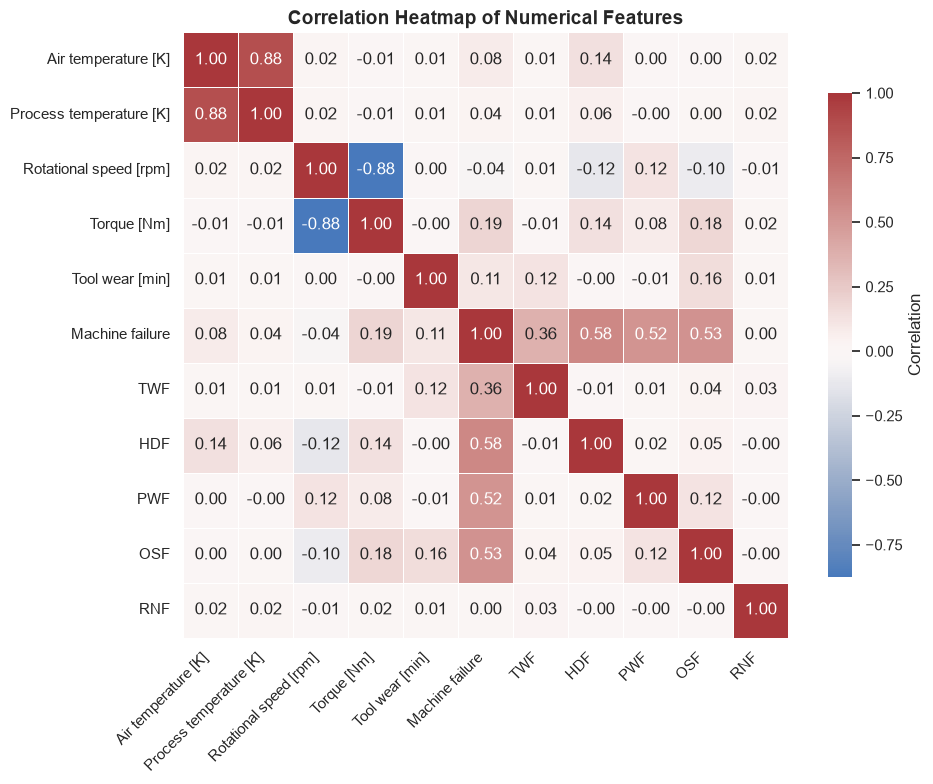

In [39]:
# Exclude identifier columns because they do not carry predictive signal.
identifier_columns = ["UDI", "Product ID"]

# Select only numerical columns and remove identifiers if they are present.
numeric_df = df.select_dtypes(include="number").drop(
    columns=identifier_columns,
    errors="ignore",
)

# Compute pairwise Pearson correlations between numerical features.
correlation_matrix = numeric_df.corr()

# Create a professional annotated correlation heatmap.
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [42]:
df.drop(columns=["UDI", "Product ID","TWF", "HDF", "PWF", "OSF", "RNF"], inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
